# Bài Tập Lớn: KHOA HỌC DỮ LIỆU
## ĐỀ TÀI: PHÂN TÍCH VÀ DỰ BÁO THỜI TIẾT TẠI VIỆT NAM


## Khởi tạo thư viện và Nạp dữ liệu

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import warnings

# Tắt các cảnh báo hệ thống để giao diện thuyết trình sạch sẽ
warnings.filterwarnings('ignore')

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc file dữ liệu gốc "Báo Cáo.pdf" có đề cập đến tệp weather.csv
df = pd.read_csv('weather.csv')

print("=== THÔNG TIN SƠ BỘ VỀ TẬP DỮ LIỆU ===")
print(f"- Số lượng bản ghi: {df.shape[0]}")
print(f"- Số lượng thuộc tính: {df.shape[1]}")
print("\n5 dòng dữ liệu đầu tiên:")
display(df.head())

=== THÔNG TIN SƠ BỘ VỀ TẬP DỮ LIỆU ===
- Số lượng bản ghi: 181960
- Số lượng thuộc tính: 10

5 dòng dữ liệu đầu tiên:


,province,max,min,wind,wind_d,rain,humidi,cloud,pressure,date
0,Bac Lieu,27,22,17,NNE,6.9,90,71,1010,2009-01-01
1,Bac Lieu,31,25,20,ENE,0.0,64,24,1010,2010-01-01
2,Bac Lieu,29,24,14,E,0.0,75,45,1008,2011-01-01
3,Bac Lieu,30,24,30,E,0.0,79,52,1012,2012-01-01
4,Bac Lieu,31,25,20,ENE,0.0,70,24,1010,2013-01-01


# PHẦN I: TIỀN XỬ LÝ DỮ LIỆU & KỸ NGHỆ ĐẶC TRƯNG
Trong phần này, hệ thống thực hiện kiểm tra giá trị khuyết thiếu, trích xuất cấu trúc chu kỳ thời gian, mã hóa một-nóng các biến phân loại định danh và chuẩn hóa thang đo số học (Z-score).

In [25]:
# 1. Kiểm tra giá trị khuyết thiếu (Missing Values)
print("=== THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU ===")
print(df.isnull().sum())

# 2. Trích xuất đặc trưng thời gian (Temporal Features)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek

# Tính toán cột nhiệt độ trung bình 'tavg' phục vụ bài toán phân tích
df['tavg'] = (df['max'] + df['min']) / 2

# 3. Mã hóa biến phân loại (Categorical Encoding) bằng One-Hot Encoding
# Giữ lại một bản sao df_eda để phục vụ phân tích thống kê theo tên tỉnh gốc
df_eda = df.copy() 

df_model = pd.get_dummies(df, columns=['province', 'wind_d'], drop_first=True)

# 4. Chuẩn hóa thang đo số học (Feature Scaling)
numerical_cols = ['max', 'min', 'wind', 'rain', 'humidi', 'cloud', 'pressure', 'tavg']
scaler = StandardScaler()
df_model[numerical_cols] = scaler.fit_transform(df_model[numerical_cols])

print("\nKích thước tập dữ liệu sau khi mã hóa đặc trưng:", df_model.shape)

=== THỐNG KÊ GIÁ TRỊ KHUYẾT THIẾU ===
province    0
max         0
min         0
wind        0
wind_d      0
rain        0
humidi      0
cloud       0
pressure    0
date        0
dtype: int64

Kích thước tập dữ liệu sau khi mã hóa đặc trưng: (181960, 67)


# PHẦN II: THỐNG KÊ VÀ PHÂN TÍCH
Sử dụng các phương pháp Gom nhóm (Aggregation), Sắp xếp phân hạng (Ranking) và Phân tách chuỗi sự kiện logic để giải mã các câu hỏi về khí hậu thực tế tại Việt Nam trong năm mục tiêu 2021.

## Top 5 tỉnh nóng nhất năm 2021

In [ ]:
# Thiết lập năm mục tiêu phân tích theo báo cáo
TARGET_YEAR = 2021

print(f"--- CÂU 1: TOP 5 TỈNH THÀNH CÓ NHIỆT ĐỘ TRUNG BÌNH CAO NHẤT NĂM {TARGET_YEAR} ---")
df_year = df_eda[df_eda['year'] == TARGET_YEAR]
top_hot_provinces = df_year.groupby('province')['tavg'].mean().sort_values(ascending=False).head(5)

# Trực quan hóa kết quả
sns.barplot(x=top_hot_provinces.values, y=top_hot_provinces.index, palette='Reds_r')
plt.title(f'Top 5 Tỉnh Thành Có Nhiệt Độ Trung Bình Cao Nhất Năm {TARGET_YEAR}')
plt.xlabel('Nhiệt độ trung bình (°C)')
plt.ylabel('Tỉnh thành')
for i, v in enumerate(top_hot_provinces.values):
    plt.text(v + 0.1, i, f"{v:.2f}°C", va='center', fontweight='bold')
plt.show()

## Tỉnh có lượng mưa tích lũy cao nhất năm 2021

In [28]:
print(f"--- CÂU 2: TỈNH THÀNH CÓ TỔNG LƯỢNG MƯA TÍCH LŨY CAO NHẤT NĂM {TARGET_YEAR} ---")
max_rain_province = df_year.groupby('province')['rain'].sum().sort_values(ascending=False).head(1)
print(f"Địa phương có lượng mưa lớn nhất: {max_rain_province.index[0]} với tổng lượng mưa {max_rain_province.values[0]:.1f} mm")

TARGET_PROVINCE = max_rain_province.index[0]

--- CÂU 2: TỈNH THÀNH CÓ TỔNG LƯỢNG MƯA TÍCH LŨY CAO NHẤT NĂM 2021 ---
Địa phương có lượng mưa lớn nhất: Hoa Binh với tổng lượng mưa 1085.5 mm


## Thống kê lượng mưa theo tháng của tỉnh mưa cao nhất

--- CÂU 3: THỐNG KÊ LƯỢNG MƯA THEO THÁNG NĂM 2021 TẠI: Hoa Binh ---


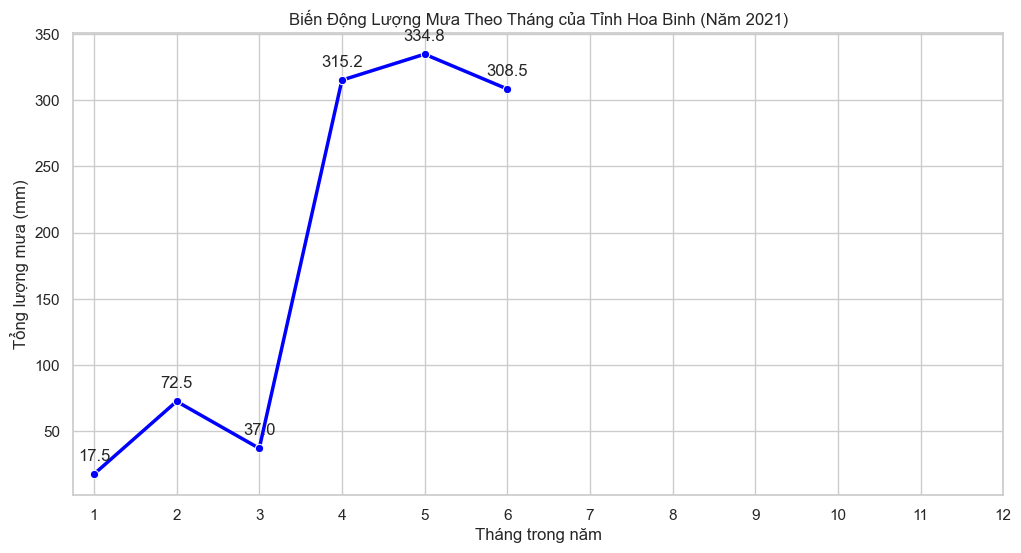

In [30]:
print(f"--- CÂU 3: THỐNG KÊ LƯỢNG MƯA THEO THÁNG NĂM {TARGET_YEAR} TẠI: {TARGET_PROVINCE} ---")
df_target_province = df_year[df_year['province'] == TARGET_PROVINCE]
monthly_rain = df_target_province.groupby('month')['rain'].sum()

# Trực quan hóa xu hướng mùa mưa theo tháng
sns.lineplot(x=monthly_rain.index, y=monthly_rain.values, marker='o', linewidth=2.5, color='blue')
plt.title(f'Biến Động Lượng Mưa Theo Tháng của Tỉnh {TARGET_PROVINCE} (Năm {TARGET_YEAR})')
plt.xlabel('Tháng trong năm')
plt.ylabel('Tổng lượng mưa (mm)')
plt.xticks(range(1, 13))
for x, y in zip(monthly_rain.index, monthly_rain.values):
    plt.text(x, y + 10, f"{y:.1f}", ha='center')
plt.show()

## Tỉnh khô hạn nhất toàn diện lịch sử

In [31]:
print("--- CÂU 4: TỈNH THÀNH CÓ LƯỢNG MƯA TRUNG BÌNH HÀNG NĂM NHỎ NHẤT TOÀN DIỆN LỊCH SỬ ---")
# Tính tổng lượng mưa từng năm của các tỉnh, sau đó tính trung bình lại để đảm bảo tính khách quan
province_yearly_rain = df_eda.groupby(['province', 'year'])['rain'].sum().reset_index()
dryest_province = province_yearly_rain.groupby('province')['rain'].mean().sort_values(ascending=True).head(1)

print(f"Địa phương khô hạn nhất: {dryest_province.index[0]} (Lượng mưa trung bình năm: {dryest_province.values[0]:.2f} mm/năm)")

--- CÂU 4: TỈNH THÀNH CÓ LƯỢNG MƯA TRUNG BÌNH HÀNG NĂM NHỎ NHẤT TOÀN DIỆN LỊCH SỬ ---
Địa phương khô hạn nhất: Nam Dinh (Lượng mưa trung bình năm: 1020.88 mm/năm)


## Tỉnh có số ngày mưa liên tục nhiều nhất năm 2021

In [32]:
print(f"--- CÂU 5: TỈNH THÀNH CÓ CHUỖI NGÀY MƯA LIÊN TỤC NHIỀU NHẤT NĂM {TARGET_YEAR} ---")

def get_max_consecutive_rain(group):
    # Tạo biến cờ hiệu: 1 nếu có mưa, 0 nếu không mưa
    is_rain = (group['rain'] > 0).astype(int)
    # Kỹ thuật cumsum tách biệt chuỗi sự kiện không ngắt quãng
    rain_groups = (is_rain == 0).cumsum()
    return is_rain.groupby(rain_groups).sum().max()

consecutive_rain_results = df_year.sort_values('date').groupby('province').apply(get_max_consecutive_rain)
max_consecutive_province = consecutive_rain_results.sort_values(ascending=False).head(1)

print(f"Kỷ lục chuỗi ngày mưa liên tục thuộc về: {max_consecutive_province.index[0]} với {max_consecutive_province.values[0]} ngày liên tiếp.")

--- CÂU 5: TỈNH THÀNH CÓ CHUỖI NGÀY MƯA LIÊN TỤC NHIỀU NHẤT NĂM 2021 ---
Kỷ lục chuỗi ngày mưa liên tục thuộc về: Vung Tau với 61 ngày liên tiếp.


# PHẦN III: XÂY DỰNG MÔ HÌNH HỌC MÁY 
Phần này hiện thực hóa 2 câu hỏi kỹ thuật :
<br>Mô hình dự báo chuỗi thời gian lượng mưa 30 ngày tiếp theo bằng XGBoost Regressor.
<br>Mô hình phân cụm đặc trưng khí hậu các tỉnh thành bằng K-Means Clustering.

## Dự đoán lượng mưa 1 tháng tới tại tỉnh điểm nóng bằng XGBoost

>> Kết quả đánh giá sai số tuyệt đối trung bình (MAE): 11.45 mm


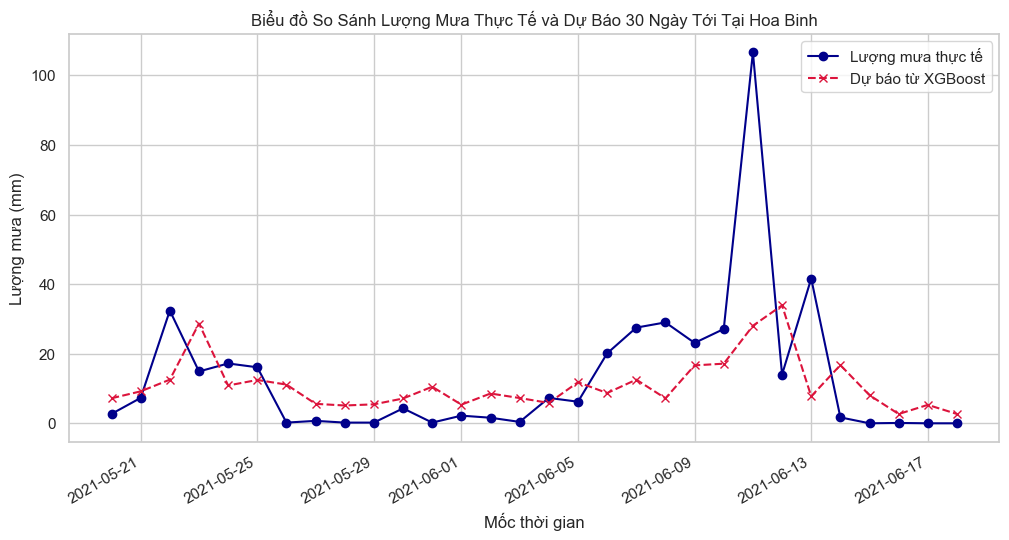

In [35]:


# Lấy dữ liệu chuỗi thời gian lịch sử của tỉnh Hòa Bình
df_ts = df_eda[df_eda['province'] == TARGET_PROVINCE].sort_values('date').reset_index(drop=True)

# Xây dựng các biến trễ (Lag features) làm dữ liệu đầu vào cho mô hình học máy giám sát
for lag in range(1, 8):
    df_ts[f'lag_{lag}'] = df_ts['rain'].shift(lag)
df_ts['rolling_mean_30'] = df_ts['rain'].shift(1).rolling(window=30).mean()

# Loại bỏ các dòng khuyết thiếu do dịch chuyển thời gian tạo ra
df_ts = df_ts.dropna().reset_index(drop=True)

# Phân chia tập dữ liệu huấn luyện và tập kiểm thử (Dự báo 30 ngày cuối)
features = [f'lag_{i}' for i in range(1, 8)] + ['rolling_mean_30', 'month', 'dayofweek']
X = df_ts[features]
y = df_ts['rain']

X_train, X_test = X.iloc[:-30], X.iloc[-30:]
y_train, y_test = y.iloc[:-30], y.iloc[-30:]
test_dates = df_ts['date'].iloc[-30:]

# Khởi tạo và huấn luyện mô hình học máy tăng cường độ dốc XGBoost
model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

# Đưa ra dự báo và đánh giá sai số thực nghiệm
predictions = model_xgb.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f">> Kết quả đánh giá sai số tuyệt đối trung bình (MAE): {mae:.2f} mm")

# Vẽ biểu đồ so sánh thực tế và dự báo chuỗi thời gian
plt.plot(test_dates, y_test.values, label='Lượng mưa thực tế', marker='o', color='darkblue')
plt.plot(test_dates, predictions, label='Dự báo từ XGBoost', marker='x', linestyle='--', color='crimson')
plt.title(f'Biểu đồ So Sánh Lượng Mưa Thực Tế và Dự Báo 30 Ngày Tới Tại {TARGET_PROVINCE}')
plt.xlabel('Mốc thời gian')
plt.ylabel('Lượng mưa (mm)')
plt.gcf().autofmt_xdate()
plt.legend()
plt.show()

## Phân cụm khí hậu bằng K-Means

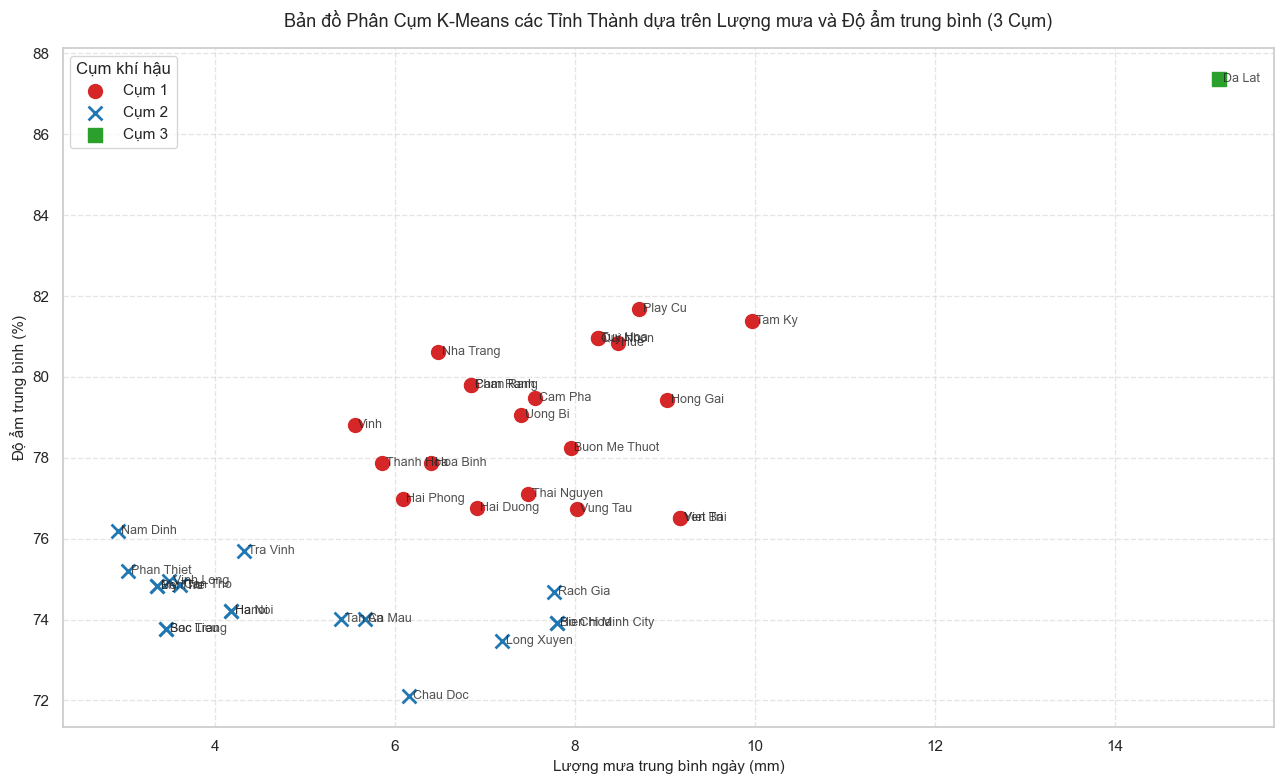


--- DANH SÁCH CÁC TỈNH THÀNH THEO TỪNG CỤM KHÍ HẬU ---

Cụm 1 (Số lượng: 21 tỉnh):
Buon Me Thuot, Cam Pha, Cam Ranh, Hai Duong, Hai Phong, Hoa Binh, Hong Gai, Hue, Nha Trang, Phan Rang, Play Cu, Qui Nhon, Tam Ky, Thai Nguyen, Thanh Hoa, Tuy Hoa, Uong Bi, Viet Tri, Vinh, Vung Tau, Yen Bai

Cụm 2 (Số lượng: 18 tỉnh):
Bac Lieu, Ben Tre, Bien Hoa, Ca Mau, Can Tho, Chau Doc, Ha Noi, Hanoi, Ho Chi Minh City, Long Xuyen, My Tho, Nam Dinh, Phan Thiet, Rach Gia, Soc Trang, Tan An, Tra Vinh, Vinh Long

Cụm 3 (Số lượng: 1 tỉnh):
Da Lat


In [39]:

# 1. Gom nhóm dữ liệu vĩ mô rút gọn để tính lượng mưa và độ ẩm trung bình ngày của từng tỉnh
df_cluster = df_eda.groupby('province')[['rain', 'humidi']].mean().reset_index()

# 2. Chuẩn hóa thang đo dữ liệu bằng StandardScaler
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(df_cluster[['rain', 'humidi']])

# 3. Khởi tạo và huấn luyện mô hình K-Means với ĐÚNG 3 cụm (K=3)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Tịnh tiến nhãn cụm từ (0, 1, 2) thành (1, 2, 3) để hiển thị trên slide cho đẹp và trực quan
df_cluster['cluster'] = df_cluster['cluster'] + 1

# 5. Khởi tạo biểu đồ phân tán (Đã tối ưu hóa kích thước để không bao giờ bị tràn RAM)
fig, ax = plt.subplots(figsize=(13, 8))

# Cấu hình danh sách màu sắc và ký hiệu (Markers) riêng biệt cho từng cụm trong 3 cụm
colors = {1: '#d62728', 2: '#1f77b4', 3: '#2ca02c'}  # Đỏ, Xanh dương, Xanh lá
markers = {1: 'o', 2: 'x', 3: 's'}                     # Tròn, Dấu x, Hình vuông

# Vẽ từng cụm độc lập lên đồ thị
for c_id in [1, 2, 3]:
    sub_cluster = df_cluster[df_cluster['cluster'] == c_id]
    ax.scatter(
        sub_cluster['rain'], 
        sub_cluster['humidi'], 
        color=colors[c_id], 
        marker=markers[c_id], 
        s=100, 
        linewidths=2 if markers[c_id]=='x' else 1,
        label=f'Cụm {c_id}'
    )

# Thiết lập tiêu đề và cấu trúc nhãn trục khí tượng
ax.set_title('Bản đồ Phân Cụm K-Means các Tỉnh Thành dựa trên Lượng mưa và Độ ẩm trung bình (3 Cụm)', fontsize=13, pad=15)
ax.set_xlabel('Lượng mưa trung bình ngày (mm)', fontsize=11)
ax.set_ylabel('Độ ẩm trung bình (%)', fontsize=11)

# 6. Duyệt bảng dữ liệu vĩ mô rút gọn để ghi tên tỉnh (Tuyệt đối an toàn, không lo MemoryError)
for idx, row in df_cluster.iterrows():
    ax.text(row['rain'] + 0.04, row['humidi'], str(row['province']), fontsize=9, va='center', alpha=0.8)

# Thêm chú thích và lưới tọa độ trực quan cho slide thuyết trình
ax.legend(title='Cụm khí hậu', loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 7. In danh sách phân bổ các tỉnh thành vào 3 cụm để đọc báo cáo/thuyết trình
print("\n--- DANH SÁCH CÁC TỈNH THÀNH THEO TỪNG CỤM KHÍ HẬU ---")
for c in [1, 2, 3]:
    prov_list = df_cluster[df_cluster['cluster'] == c]['province'].tolist()
    print(f"\nCụm {c} (Số lượng: {len(prov_list)} tỉnh):")
    print(", ".join(prov_list))